# Initialization

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from fun_gilles import *
import cmcrameri.cm as cmc
import pandas as pd
import pickle
colors = plt.get_cmap('Set2').colors
title_fs = 16
label_fs = 15
tick_fs = 14
legend_fs = 14

In [3]:
def load_streamed_pickle(filename):
    data = {}
    try:
        with open(filename, "rb") as file:
            while True:
                try:
                    # Load one object (which is a dict of {k_i: (abundances, times, volumes)})
                    chunk = pickle.load(file)
                    # Merge the loaded chunk into the main dictionary
                    data.update(chunk)
                except EOFError:
                    # Reached the end of the file
                    break
    except FileNotFoundError:
        print(f"Error: File '{filename}' not found.")
    
    print(f"Successfully loaded {len(data)} simulation results.")
    return data

In [4]:
def plot(abundances, times, V, SPECIES):
    colors = plt.get_cmap('Set2').colors
    colors = colors

    # --- Create the figure and a 1-row, 3-column subplot grid ---
    # Using a wide figsize for a horizontal layout.
    fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True) 
    # Note: sharex=True is removed because we need the x-axis ticK_CONSTANTSs on all three plots, 
    # although they are the same (time).

    # --- Subplot 1 (Left): Concentration ---
    ax1 = axes[0]
    for i in range(len(SPECIES)):
        # Calculate Concentration = Abundance / Volume
        ax1.plot(times, abundances[:, i] / V, label=SPECIES[i], color=colors[i], alpha=0.9)
    ax1.grid(True, linestyle='--', alpha=0.3)
    ax1.set_xlabel("Time", fontsize= label_fs)
    ax1.set_ylabel("Concentration", fontsize= label_fs)
    ax1.set_title("Concentration Evolution", fontsize= title_fs)
    ax1.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), title="SPECIES", fontsize= legend_fs)
    ax1.tick_params(axis='both', labelsize=tick_fs)

    # --- Subplot 2 (Middle): Volume ---
    ax2 = axes[1]
    ax2.plot(times, V, color='gray')
    ax2.grid(True, linestyle='--', alpha=0.3)
    ax2.set_xlabel("Time", fontsize= label_fs)
    ax2.set_ylabel("Volume", fontsize= label_fs)
    ax2.set_title("Volume Evolution", fontsize= title_fs)
    ax2.tick_params(axis='both', labelsize=tick_fs)


    # These actions must run regardless of the title set, so they replace 'finally'
    plt.tight_layout(rect=[0, 0, 1, 1]) # Adjust tight_layout for a single row
    plt.show()

In [5]:
def plot_both(abundances_to, times_to, V_to, SPECIES_to,
              abundances_in, times_in, V_in, SPECIES_in):
    
    colors = plt.get_cmap('Set2').colors
    colors = colors
# 1. Determine the common time limit
    # We find the end time of both and pick the smaller one
    max_time_to = max(times_to)
    max_time_in = max(times_in)
    common_end_time = min(max_time_to, max_time_in)
        
    # --- Create the figure and a 1-row, 3-column subplot grid ---
    # Using a wide figsize for a horizontal layout.
    fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True) 
    # Note: sharex=True is removed because we need the x-axis ticK_CONSTANTSs on all three plots, 
    # although they are the same (time).

    # --- Subplot 1 (Left): Concentration ---
    ax1 = axes[0]
    for i in range(len(SPECIES_to)):
        # Calculate Concentration = Abundance / Volume
        ax1.plot(times_to, abundances_to[:, i] / V_to, label=f"{SPECIES_to[i]} T.O.", color=colors[i], alpha=0.6, linestyle= "--")
    for i in range(len(SPECIES_in)):
        # Calculate Concentration = Abundance / Volume
        ax1.plot(times_in, abundances_in[:, i] / V_in, label=f"{SPECIES_in[i]} int", color=colors[i], alpha=0.6)
    ax1.grid(True, linestyle='--', alpha=0.3)
    ax1.set_ylabel("Concentration", fontsize= label_fs)
    ax1.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), title="SPECIES", fontsize= legend_fs)
    ax1.tick_params(axis='both', labelsize=tick_fs)
    ax1.set_xlim(0, common_end_time)

    # --- Subplot 2 (Middle): Volume ---
    ax2 = axes[1]
    ax2.plot(times_to, V_to, color='gray', linestyle= "--")
    ax2.plot(times_in, V_in, color='gray')
    ax2.grid(True, linestyle='--', alpha=0.3)
    ax2.set_xlabel("Time", fontsize= label_fs)
    ax2.set_ylabel("Volume", fontsize= label_fs)
    ax2.tick_params(axis='both', labelsize=tick_fs)
    ax2.set_xlim(0, common_end_time)
    ax2.set_yscale('log')


    # These actions must run regardless of the title set, so they replace 'finally'
    plt.show()

In [6]:
third_order = "../examples/third_order.txt"
intermediates = "../examples/reactions_autocat.txt"

# simulation
method = "Protocell"
initial_species = [1000]*4 + [100]*2+[0]*2
initial_species_third = [1000]*4 + [100]*2
k_third_order = [1]*4
k_intermediates = [1]*8
V = 1000
iterations = 1e5
sp_intermediates = obtain_species(read_file(intermediates))
sp_thirdorder = obtain_species(read_file(third_order))


# Simulations

## Intermediarios

Criterion for stop was # of iterations


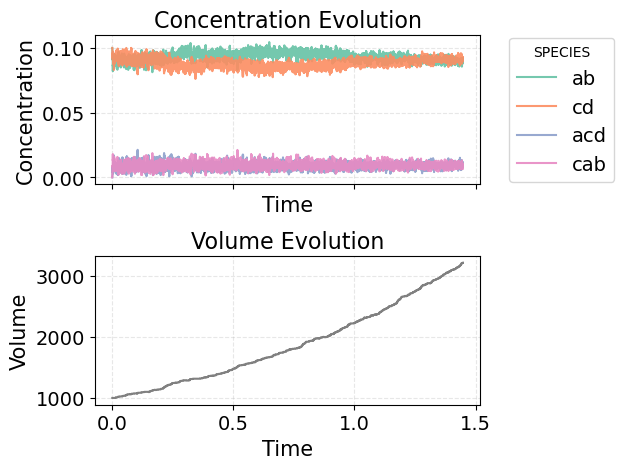

In [8]:
k_1_2_ratio = 1e-1
k_intermediates[1] = 1e3
k_intermediates[0] = k_intermediates[1] * k_1_2_ratio
k_intermediates[2] = k_intermediates[1] / k_intermediates[0]

k_intermediates[5] = 1e3
k_intermediates[4] = k_intermediates[5] * k_1_2_ratio
k_intermediates[6] = k_intermediates[5] / k_intermediates[4]

V_in = 1000
abundances_in, times_in, volumesMM_in = chemistry(method, iterations, intermediates, 
                                       initial_species, k_intermediates, V_in)
plot(abundances_in[:,4:], times_in, volumesMM_in, sp_intermediates[4:])


## Third order

In [9]:

abundances_TO, timesTO, volumesTO = chemistry(method, iterations, third_order, 
                                       initial_species_third, k_third_order, 1000)

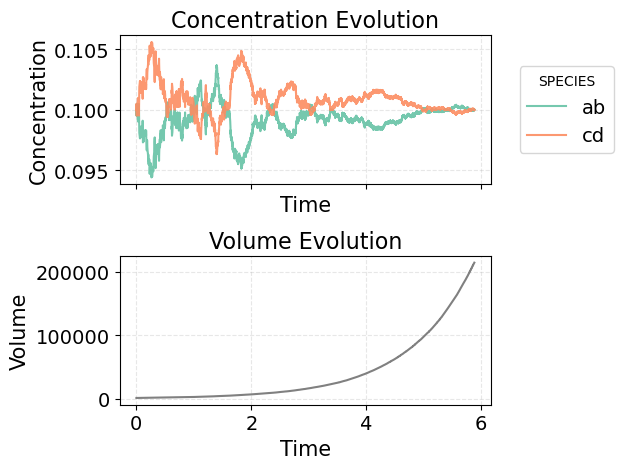

In [10]:
plot(abundances_TO[:,4:], timesTO, volumesTO, sp_thirdorder[4:])

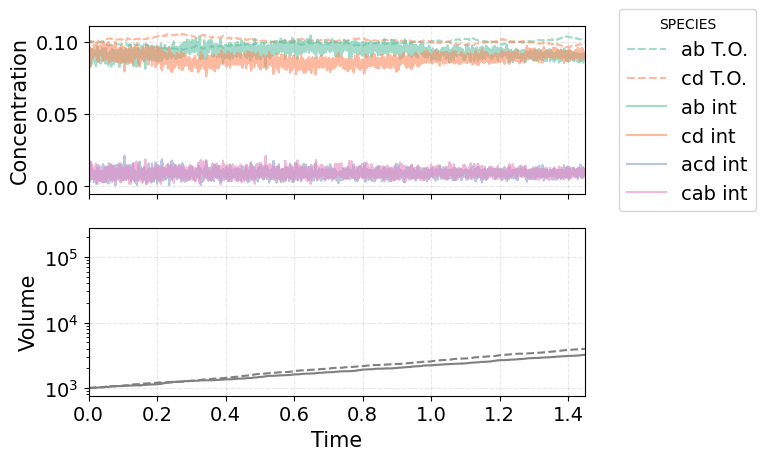

In [11]:
plot_both(abundances_TO[:,4:],timesTO, volumesTO, sp_thirdorder[4:],
          abundances_in[:,4:], times_in, volumesMM_in, sp_intermediates[4:])


Criterion for stop was # of iterations
Criterion for stop was # of iterations
Criterion for stop was # of iterations
Criterion for stop was # of iterations
Criterion for stop was # of iterations
Criterion for stop was # of iterations


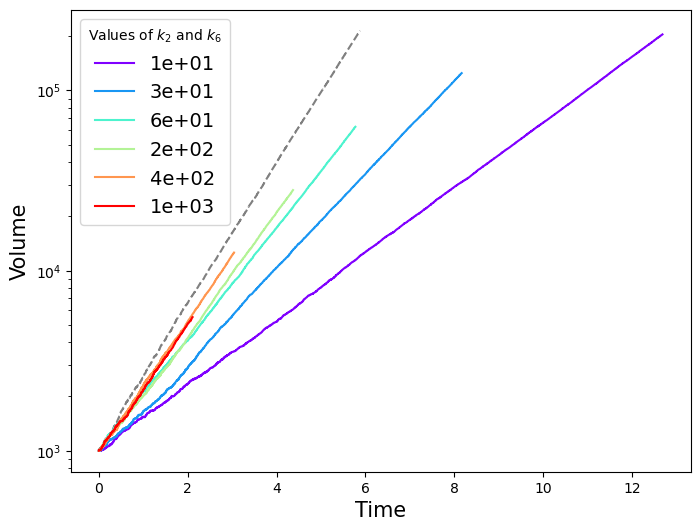

In [ ]:
V_in = 1000
plt.figure(figsize=(8,6))
plt.plot(timesTO, volumesTO, color='gray', linestyle= "--")
colors = plt.cm.rainbow(np.linspace(0, 1, 6))
int_results = {}

for i, k in enumerate(np.logspace(1,3, num=6)):
    k_intermediates[1] = k
    k_intermediates[0] = k_intermediates[1] * k_1_2_ratio
    k_intermediates[2] = k_intermediates[1] / k_intermediates[0]

    k_intermediates[5] = k
    k_intermediates[4] = k_intermediates[5] * k_1_2_ratio
    k_intermediates[6] = k_intermediates[5] / k_intermediates[4]

    abundances_in, times_in, volumesMM_in = chemistry(method, 2e5, intermediates, 
                                        initial_species, k_intermediates, V_in, threshold= 0)
    int_results[k] = (abundances_in, times_in, volumesMM_in)
    plt.plot(times_in, volumesMM_in, color=colors[i], label=f"{k:.0e}")

plt.yscale('log')
plt.xlabel("Time", fontsize = label_fs)
plt.ylabel("Volume", fontsize = label_fs)
    
plt.legend(title=r"Values of $k_2$ and $k_6$", fontsize= legend_fs)

{0: (array([[1.000e+02, 1.000e+02, 1.000e+02, ..., 0.000e+00, 0.000e+00,
          0.000e+00],
         [1.000e+02, 1.000e+02, 1.000e+02, ..., 0.000e+00, 0.000e+00,
          1.000e+00],
         [1.000e+02, 1.000e+02, 1.000e+02, ..., 0.000e+00, 0.000e+00,
          2.000e+00],
         ...,
         [1.335e+03, 1.335e+03, 1.335e+03, ..., 1.330e+02, 9.000e+00,
          1.200e+01],
         [1.335e+03, 1.335e+03, 1.335e+03, ..., 1.320e+02, 1.000e+01,
          1.200e+01],
         [1.335e+03, 1.335e+03, 1.335e+03, ..., 1.320e+02, 1.000e+01,
          1.300e+01]]),
  array([0.00000000e+00, 2.03177590e-04, 6.81911077e-04, ...,
         3.54182795e+00, 3.54184393e+00, 3.54188730e+00]),
  array([ 100.,  100.,  100., ..., 1335., 1335., 1335.])),
 1: (array([[100., 100., 100., ...,   0.,   0.,   0.],
         [100., 100., 100., ...,   0.,   0.,   1.],
         [100., 100., 100., ...,   0.,   0.,   2.],
         ...,
         [535., 535., 535., ...,  45.,   4.,   5.],
         [535., 535., 53

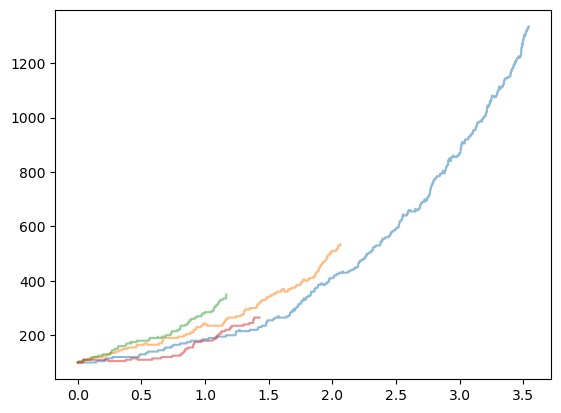

In [10]:
results = {}
with open("intermediates_k1sweep2026-03-13_0152.pkl", "rb") as file:
    while True:
        try:
            results.update(pickle.load(file))
        except EOFError:
            break

for k, (abundances_in, times_in, volumesMM_in) in results.items():
    plt.plot(times_in, volumesMM_in, label=f"{k:.0e}", alpha= 0.5)
    
results

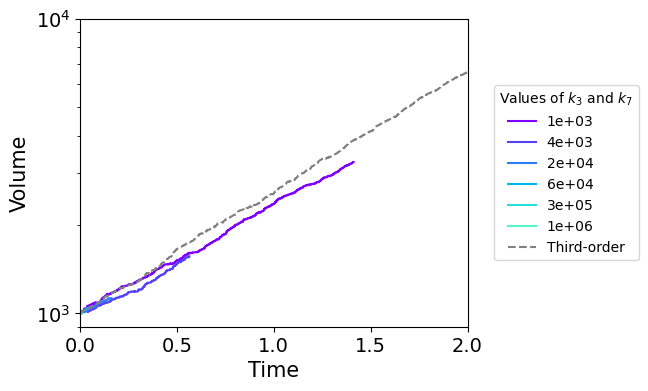

In [15]:
plt.figure(figsize=(5,4))
colors = plt.cm.rainbow(np.linspace(0, 1, 13))
i = 0
for k, result in int_results.items():
    abundances_in, times_in, volumesMM_in = result
    plt.plot(times_in, volumesMM_in, color=colors[i], label=f"{k:.0e}")
    i += 1
plt.plot(timesTO, volumesTO, color='gray', linestyle= "--", label="Third-order")
plt.yscale('log')
plt.xlabel("Time", fontsize = label_fs)
plt.ylabel("Volume", fontsize = label_fs)
plt.xlim(0, 2)
plt.ylim(9e2, 1e4)
plt.tick_params(axis='both', labelsize=tick_fs)



    
plt.legend(title=r"Values of $k_3$ and $k_7$", loc='center left', bbox_to_anchor=(1.05, 0.5))